In [1]:
! git clone https://github.com/tapichugina/Simple_Pytorch_Img_Project.git
! pip install torchinfo

Cloning into 'Simple_Pytorch_Img_Project'...
remote: Enumerating objects: 54, done.
remote: Counting objects: 100% (54/54), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 54 (delta 17), reused 35 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (54/54), 9.37 MiB | 11.12 MiB/s, done.
Resolving deltas: 100% (17/17), done.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import torch
import torchvision
from torch import nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR, ReduceLROnPlateau,MultiStepLR, CyclicLR, LambdaLR
from torch.utils.data import Dataset, DataLoader,WeightedRandomSampler
import torchvision.datasets as datasets
from torchvision.transforms.v2 import Compose, Normalize,Resize,ToImage,ToDtype,RandomCrop,RandomHorizontalFlip
from torch.utils.data import random_split
from torchinfo import summary

from sklearn.metrics import f1_score, confusion_matrix, classification_report



from pathlib import Path
import sys
PROJECT_ROOT = Path("/content/Simple_Pytorch_Img_Project")
sys.path.insert(0, str(PROJECT_ROOT))

from utils.train import StepByStep
from utils.overfit_single_batch import overfit_single_batch
from utils.calculate_img_statistics import calculate_statistics

ModuleNotFoundError: No module named 'utils'

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Data_Folder="/content/drive/MyDrive/Image_Classification/data/CIFAR10"
Runs_Folder="/content/drive/MyDrive/Image_Classification/runs"
Log_Folder="/content/drive/MyDrive/Image_Classification/logs"
Checkpoints_Folder="/content/drive/MyDrive/Image_Classification/checkpoints"

Mounted at /content/drive


In [9]:
# # %load_ext autoreload
# # %autoreload 2

# import importlib
# import utils.train

# importlib.reload(utils.train)


# Data

### CIFAR

size of single image
32x32x3

* Train 50000
* Test  10000


0. 'airplane',
1. 'automobile',
2. 'bird',
3. 'cat',
4. 'deer',
5. 'dog',
6. 'frog',
7. 'horse',
8. 'ship',
9. 'truck'

In [4]:
transform_train = Compose([
    RandomCrop(32, padding=4),
    RandomHorizontalFlip(),
    ToImage(),
    ToDtype(torch.float32, scale=True),
    Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))])

transform_val = Compose([
    ToImage(),
    ToDtype(torch.float32, scale=True),
    Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))])


train_dataset = torchvision.datasets.CIFAR10(
    root=Data_Folder,
    train=True,
    transform=transform_train,
    download=False
)

test_dataset = torchvision.datasets.CIFAR10(
    root=Data_Folder,
    train=False,
    transform=transform_val,
    download=False
)

In [5]:
train_loader=DataLoader(train_dataset,batch_size=128,shuffle=True)
val_loader=DataLoader(test_dataset,batch_size=128,shuffle=False)

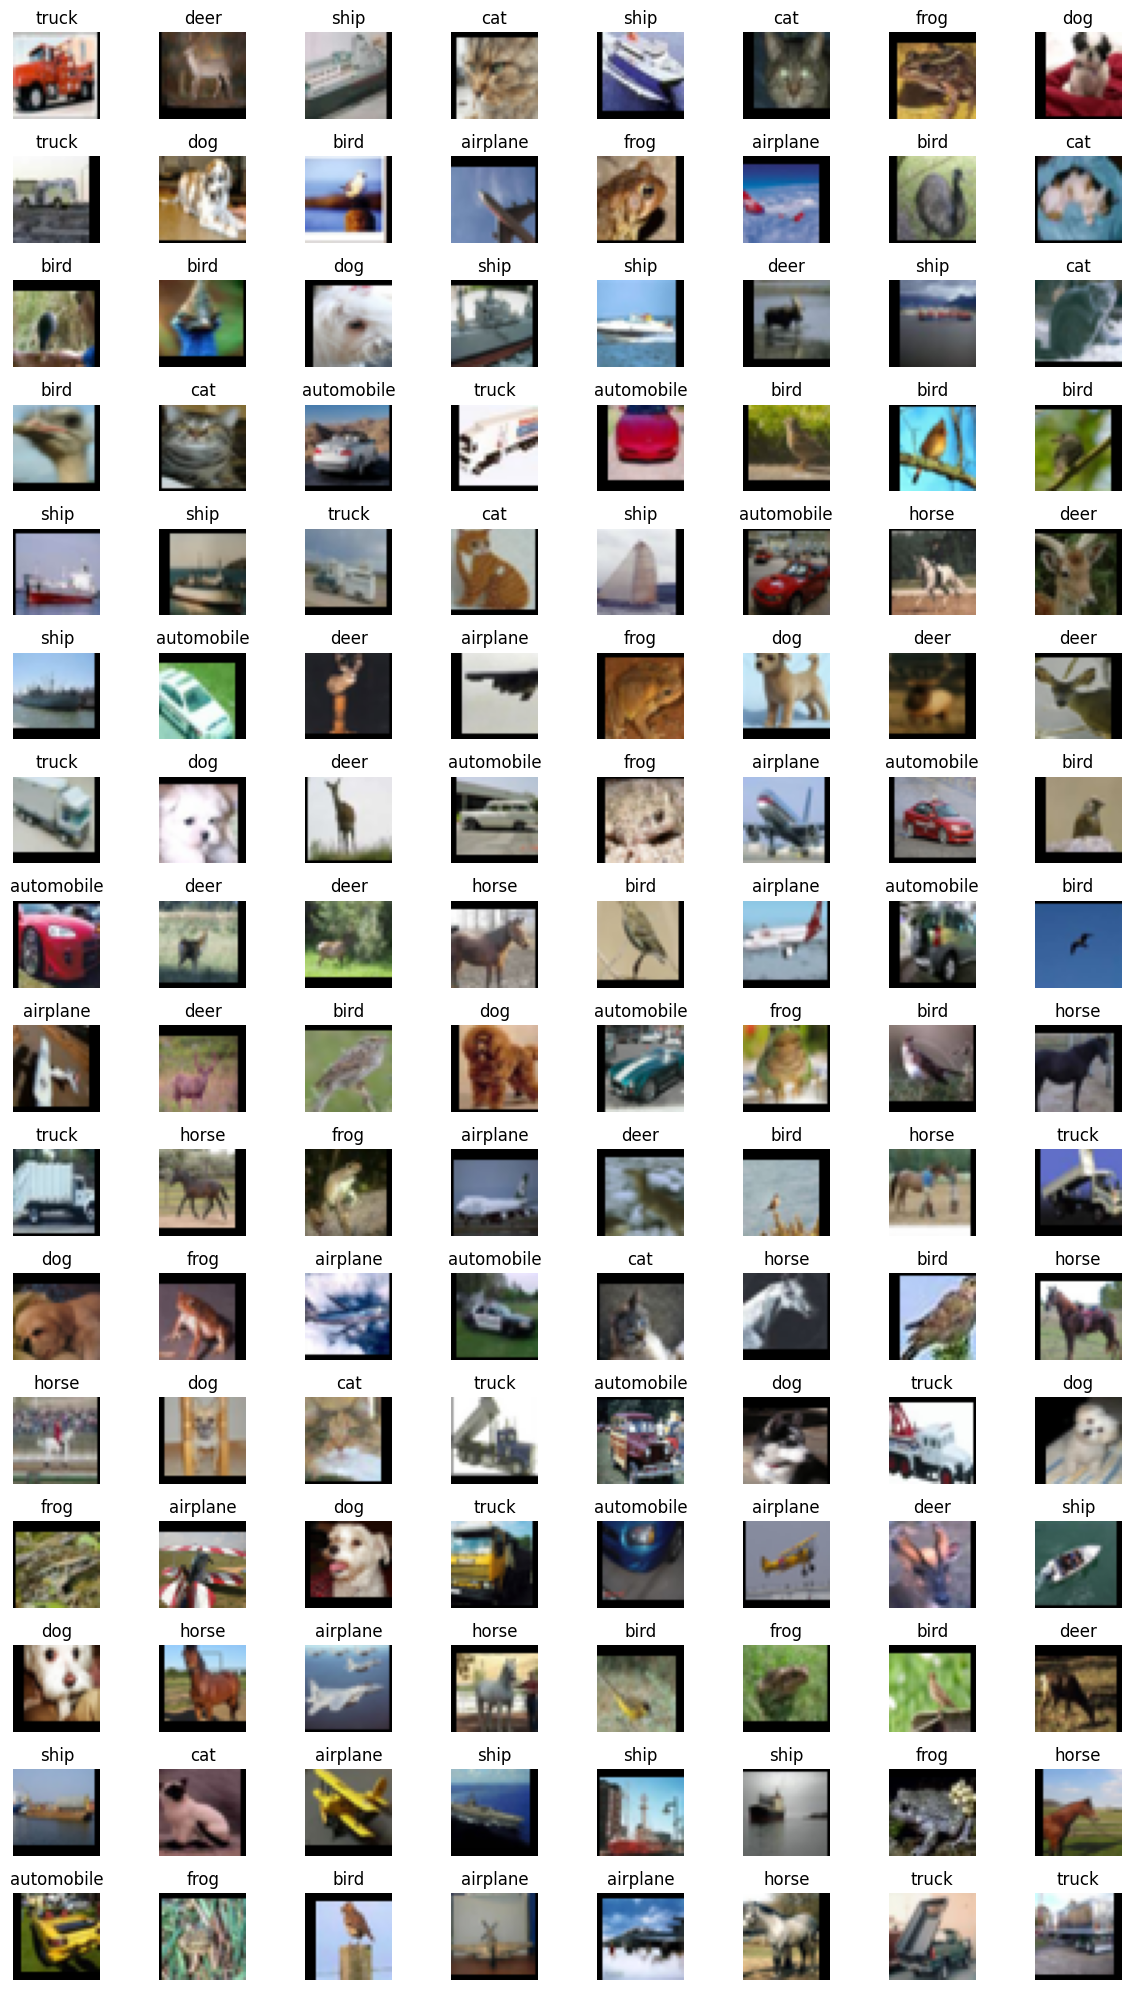

In [6]:
batch, labels = next(iter(train_loader))

mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)

# Undo normalization
batch = batch * std + mean


fig, axes = plt.subplots(16, 8, figsize=(12, 20))

for image, label, ax in zip(batch, labels, axes.flat):
    image = image.permute(1, 2, 0)

    ax.imshow(image)
    ax.set_title(train_dataset.classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()


## Model

In [ ]:
#Block of ResNet
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
    super().__init__()

    self.conv1 = nn.Conv2d(in_channels,out_channels,kernel_size=3,stride=stride,padding=1)
    self.bn1 = nn.BatchNorm2d(out_channels)
    self.conv2 = nn.Conv2d(out_channels,out_channels,kernel_size=3,stride=1,padding=1)
    self.bn2 = nn.BatchNorm2d(out_channels)

    # Shortcut
    if stride != 1 or in_channels != out_channels:
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_channels,out_channels,kernel_size=1,stride=stride),
            nn.BatchNorm2d(out_channels)
        )
    else:
        self.shortcut = nn.Identity()

    self.relu = nn.ReLU()

def forward(self, x):

    identity = self.shortcut(x)

    out = self.conv1(x)
    out = self.bn1(out)
    out = self.relu(out)

    out = self.conv2(out)
    out = self.bn2(out)

    out = out + identity

    out = self.relu(out)

    return out

In [ ]:
class ResNet18(nn.Module):
     def __init__(self,num_classes=10):
          super().__init__()
          self.head=nn.Sequential(
                  nn.LazyConv2d(64, kernel_size=3, stride=1, padding=1),
                  nn.LazyBatchNorm2d(), nn.ReLU())

          self.residual=nn.Sequential(

            # 64 channels
            ResidualBlock(64, 64),
            ResidualBlock(64, 64),

            # 128 channels
            ResidualBlock(64, 128, stride=2),
            ResidualBlock(128, 128),

            # 256 channels
            ResidualBlock(128, 256, stride=2),
            ResidualBlock(256, 256),

            # 512 channels
            ResidualBlock(256, 512, stride=2),
            ResidualBlock(512, 512),
        )

          self.classification=nn.Sequential(
               nn.AdaptiveAvgPool2d((1, 1)), 
               nn.Flatten(),
               nn.LazyLinear(num_classes))
     
     
     
     def forward(self,x):
         x=self.head(x)
         x=self.residual(x)
         x=self.classification(x)
         
         
    

In [ ]:
torch.manual_seed(13)


model=ResNet18()
x=torch.rand(1,3,32,32)
model(x)
summary(model, input_size=(1, 3, 32, 32))


Layer (type:depth-idx)                   Output Shape              Param #
small_VGG                                [1, 10]                   --
├─Sequential: 1-1                        [1, 10]                   --
│    └─Sequential: 2-1                   [1, 16, 16, 16]           --
│    │    └─Conv2d: 3-1                  [1, 16, 32, 32]           448
│    │    └─ReLU: 3-2                    [1, 16, 32, 32]           --
│    │    └─MaxPool2d: 3-3               [1, 16, 16, 16]           --
│    └─Sequential: 2-2                   [1, 32, 8, 8]             --
│    │    └─Conv2d: 3-4                  [1, 32, 16, 16]           4,640
│    │    └─ReLU: 3-5                    [1, 32, 16, 16]           --
│    │    └─Conv2d: 3-6                  [1, 32, 16, 16]           9,248
│    │    └─ReLU: 3-7                    [1, 32, 16, 16]           --
│    │    └─MaxPool2d: 3-8               [1, 32, 8, 8]             --
│    └─Sequential: 2-3                   [1, 64, 4, 4]             --
│    │  

In [ ]:
RunName="ResNet18"
loss=nn.CrossEntropyLoss(reduction='mean')
optimizer=optim.AdamW(model.parameters(),lr=3e-4,weight_decay=1e-2)
#optimizer=optim.SGD(model_cnn2.parameters(),lr=0.025,momentum=0.9)
#scheduler=StepLR(optimizer,step_size=5,gamma=0.5)

sbs=StepByStep(model,loss,optimizer)
sbs.set_loaders(train_loader,val_loader)
sbs.set_tensorboard(RunName,Runs_Folder)


In [19]:
# layers_to_hook = [
#     "net.0.0",   # Conv2d(3, 16, ...)
#     "net.1.0",   # Conv2d(16, 32, ...)
#     "net.2.0",   # Conv2d(32, 64, ...)
#     "net.4",     # Linear(4096, 4096, ...)
#     "net.10"     # Linear(4096, 10, ...)
# ]
# print(layers_to_hook)

# df=sbs.diagnostic_epoch(sbs.train_loader,layers_to_hook=layers_to_hook)
# summary=sbs.summarize_epoch(df)
# summary.to_csv(f"{RunName}_after_1 epoch_calculation.csv")
# print(summary)

In [20]:
sbs.train(15)
sbs.save_checkpoint(f"{Checkpoints_Folder}/checkpoint-{RunName}.pth")

Epoch [0/15] -> Train Loss: 1.8276 | Val Loss: 1.7180 | F1_ score: 0.2891
Epoch [1/15] -> Train Loss: 1.7296 | Val Loss: 1.6397 | F1_ score: 0.3204
Epoch [2/15] -> Train Loss: 1.6766 | Val Loss: 1.5641 | F1_ score: 0.3565
Epoch [3/15] -> Train Loss: 1.6119 | Val Loss: 1.4943 | F1_ score: 0.4010
Epoch [4/15] -> Train Loss: 1.5484 | Val Loss: 1.4076 | F1_ score: 0.4485
Epoch [5/15] -> Train Loss: 1.4867 | Val Loss: 1.4028 | F1_ score: 0.4258
Epoch [6/15] -> Train Loss: 1.4264 | Val Loss: 1.2914 | F1_ score: 0.4858
Epoch [7/15] -> Train Loss: 1.3685 | Val Loss: 1.2253 | F1_ score: 0.5370
Epoch [8/15] -> Train Loss: 1.3118 | Val Loss: 1.2008 | F1_ score: 0.5394
Epoch [9/15] -> Train Loss: 1.2525 | Val Loss: 1.1240 | F1_ score: 0.5796
Epoch [10/15] -> Train Loss: 1.2231 | Val Loss: 1.0792 | F1_ score: 0.6013
Epoch [11/15] -> Train Loss: 1.1612 | Val Loss: 1.0653 | F1_ score: 0.6041
Epoch [12/15] -> Train Loss: 1.1363 | Val Loss: 1.0128 | F1_ score: 0.6325
Epoch [13/15] -> Train Loss: 1.0963

In [17]:
# %load_ext tensorboard
# %tensorboard --logdir "$Runs_Folder"

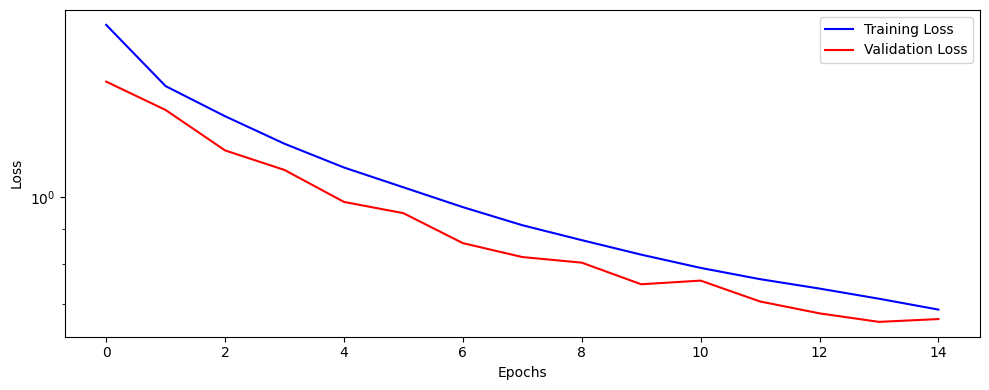

In [33]:
sbs.plot_losses();